# Autoimmune cloud — 01. Dependency graphs and load propagation

**CITS4403 research project**

**Claim under test:** automated defence is itself a contagion process on the
infrastructure it protects, and past a critical detector sensitivity it causes
more outage than the attack it prevents.

**Research question.** How do detector sensitivity, response aggressiveness, and
infrastructure topology jointly determine total system damage in an automated
cloud defence system?

---

### What this notebook does

This is step 1 of the build. Everything later in the project — worm spreading,
capacity cascades, the anomaly detector, quarantine response — runs on top of a
dependency graph carrying load. If the load model is wrong, every downstream
result is wrong, so this notebook builds it and validates it before anything
else is added.

Specifically:

1. Generate microservice dependency graphs under three topologies.
2. Solve for the steady-state load each service carries.
3. Validate the solver against an exact reference solution.
4. Compare the three topologies and show why topology alone changes how much
   damage a single failure does.

### The system being modelled

A microservice platform is a directed graph. Nodes are services, and an edge
`i -> j` means "service `i` calls service `j`". Requests enter at gateway
services and propagate downstream, amplified along the way because one request
served at `i` may require several calls to `j`.

Two properties of this graph drive the whole project:

- **Services have finite capacity.** If one is removed, its traffic lands on the
  survivors, which can push them over their limit. That is a cascade.
- **Load is unevenly distributed.** In graphs with hubs, a small number of shared
  services (auth, config, the data layer) carry most of the traffic.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

SEED = 42
EXTERNAL_RATE = 100.0   # requests/sec arriving at each entry service
N_NODES = 300

print(f"networkx {nx.__version__} | numpy {np.__version__}")

networkx 3.6.1 | numpy 2.1.3


## 1. Graph generators

Three topologies. All produce directed **acyclic** graphs, so a call chain can
never loop back on itself.

**Barabási–Albert (scale-free).** Preferential attachment: new services
preferentially call already-popular ones. Edges are oriented from the
later-arriving node to the earlier one, which makes early services high
*in-degree* hubs. That is the auth-service and shared-database pattern.

**Erdős–Rényi (random).** Every possible call edge exists with equal
probability. No hubs. Included as the control: same node count, same mean
degree, different structure.

**Layered.** Gateway → business logic → platform → data, with preferential
attachment *within* each layer transition. The most realistic of the three, and
the one used as the primary topology for the main experiments.

Each edge carries a weight `w` — the expected number of calls to `j` per request
served at `i`.

In [2]:
def _weights(G, rng, lo=0.6, hi=1.6):
    """Call multiplicity: expected calls to j per request served at i."""
    for u, v in G.edges():
        G[u][v]["w"] = rng.uniform(lo, hi)
    return G


def build_ba(n=N_NODES, m=2, seed=None):
    """Scale-free. Oriented new -> old, giving heavy-tailed in-degree."""
    rng = np.random.default_rng(seed)
    und = nx.barabasi_albert_graph(n, m, seed=int(rng.integers(1 << 30)))
    G = nx.DiGraph(); G.add_nodes_from(range(n))
    for u, v in und.edges():
        caller, callee = (u, v) if u > v else (v, u)
        G.add_edge(caller, callee)
    return _weights(G, rng)


def build_er(n=N_NODES, mean_degree=4.0, seed=None):
    """Random graph, matched on node count and mean degree."""
    rng = np.random.default_rng(seed)
    p = mean_degree / (n - 1)
    G = nx.DiGraph(); G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i):
            if rng.random() < p:
                G.add_edge(i, j)
    return _weights(G, rng)


def build_layered(layer_sizes=(20, 60, 120, 60, 40), fanout=3, seed=None):
    """Gateway -> logic -> platform -> data, preferential within transitions."""
    rng = np.random.default_rng(seed)
    G = nx.DiGraph(); layers, nid = [], 0
    for size in layer_sizes:
        layers.append(list(range(nid, nid + size))); nid += size
    G.add_nodes_from(range(nid))
    for li in range(len(layers) - 1):
        targets = layers[li + 1]
        skip = layers[li + 2] if li + 2 < len(layers) else None
        counts = np.ones(len(targets))
        for caller in layers[li]:
            k = min(fanout, len(targets))
            chosen = rng.choice(len(targets), size=k, replace=False,
                                p=counts / counts.sum())
            for idx in chosen:
                G.add_edge(caller, targets[idx]); counts[idx] += 1.0
            if skip is not None and rng.random() < 0.25:
                G.add_edge(caller, skip[rng.integers(len(skip))])
    for n_ in G.nodes():
        G.nodes[n_]["layer"] = next(i for i, L in enumerate(layers) if n_ in L)
    return _weights(G, rng)


GRAPHS = {
    "BA (scale-free)": build_ba(seed=SEED),
    "ER (random)":     build_er(seed=SEED),
    "Layered":         build_layered(seed=SEED),
}

for name, G in GRAPHS.items():
    print(f"{name:18s} nodes={G.number_of_nodes():4d} edges={G.number_of_edges():4d} "
          f"mean degree={2*G.number_of_edges()/G.number_of_nodes():.2f}")

BA (scale-free)    nodes= 300 edges= 596 mean degree=3.97
ER (random)        nodes= 300 edges= 617 mean degree=4.11
Layered            nodes= 300 edges= 826 mean degree=5.51


## 2. Load propagation

Load enters at **entry nodes** (services with in-degree zero — nothing internal
calls them) and flows downstream:

$$L_j = e_j + \sum_{i \,\in\, \text{live callers}} L_i \, w_{ij}$$

where $e_j$ is external arrival rate (non-zero only at entry nodes).

Solved by iterating to a fixed point. On a DAG a single topological pass would
be exact and cheaper, but the iterative form is used so the same code still
works later when retry loops introduce cycles.

The `removed` argument is what makes this reusable for the whole project: a
removed service — failed, compromised, or **quarantined** — carries no load and
forwards none, so its traffic redistributes to whatever is left. That
redistribution is the cascade mechanism.

Capacity is then $C_i = (1+\alpha) L_i$, where $\alpha$ is spare capacity. This
is the standard convention in the cascading-failure literature and gives a
single global control parameter.

In [3]:
def propagate_load(G, external_rate=EXTERNAL_RATE, removed=None,
                   max_iter=500, tol=1e-9):
    """Steady-state per-node request rate. Removed nodes carry and forward none."""
    removed = set() if removed is None else set(removed)
    live = [n for n in G.nodes() if n not in removed]
    entries = {n for n in G.nodes() if G.in_degree(n) == 0}

    L = {n: (external_rate if n in entries else 0.0) for n in live}
    for _ in range(max_iter):
        new = {n: (external_rate if n in entries else 0.0) for n in live}
        for i in live:
            if L[i] == 0.0:
                continue
            for j in G.successors(i):
                if j not in removed:
                    new[j] += L[i] * G[i][j]["w"]
        delta = max((abs(new[n] - L[n]) for n in live), default=0.0)
        L = new
        if delta < tol:
            break
    else:
        raise RuntimeError("load propagation did not converge")
    for n in removed:
        L[n] = 0.0
    return L


def exact_dag_load(G, external_rate=EXTERNAL_RATE):
    """Reference solution by topological order. Used only for validation."""
    entries = {n for n in G.nodes() if G.in_degree(n) == 0}
    L = {n: (external_rate if n in entries else 0.0) for n in G.nodes()}
    for i in nx.topological_sort(G):
        for j in G.successors(i):
            L[j] += L[i] * G[i][j]["w"]
    return L


def assign_capacity(L, alpha):
    """C_i = (1 + alpha) L_i. alpha is the spare-capacity control parameter."""
    return {n: (1.0 + alpha) * l for n, l in L.items()}


LOADS = {name: propagate_load(G) for name, G in GRAPHS.items()}
print("load solved for all three topologies")

load solved for all three topologies


## 3. Validation

Four checks. Each is a way the model could be silently wrong.

In [4]:
print("=" * 64)
for name, G in GRAPHS.items():
    L = LOADS[name]

    # (1) acyclicity: a call chain must never loop back
    assert nx.is_directed_acyclic_graph(G), f"{name} is not a DAG"

    # (2) iterative solver must agree with the exact topological solution
    Lx = exact_dag_load(G)
    rel = max(abs(L[n] - Lx[n]) for n in G.nodes()) / max(Lx.values())
    assert rel < 1e-9, f"{name}: solver mismatch {rel:.2e}"

    # (3) removing the busiest node must reduce total served work
    hub = max(L, key=L.get)
    after = propagate_load(G, removed={hub})
    tb, ta = sum(L.values()), sum(after.values())
    assert ta < tb

    # (4) capacity must never be below current load
    C = assign_capacity(L, alpha=0.5)
    assert all(C[n] >= L[n] - 1e-12 for n in G.nodes())

    print(f"{name}")
    print(f"   acyclic ok | solver max rel err {rel:.1e} | capacity ok")
    print(f"   removing busiest node {hub}: served work "
          f"{tb:,.0f} -> {ta:,.0f}  ({100*(1-ta/tb):.1f}% lost)")
print("=" * 64)
print("all checks passed")

BA (scale-free)
   acyclic ok | solver max rel err 4.4e-16 | capacity ok
   removing busiest node 0: served work 2,231,700 -> 1,181,218  (47.1% lost)
ER (random)
   acyclic ok | solver max rel err 1.9e-16 | capacity ok
   removing busiest node 16: served work 283,373 -> 269,346  (4.9% lost)
Layered
   acyclic ok | solver max rel err 3.4e-16 | capacity ok
   removing busiest node 267: served work 587,473 -> 545,133  (7.2% lost)
all checks passed


### What check 3 already tells us

Removing exactly one service costs a very different amount of served work
depending only on topology. Nothing has been attacked and no detector exists
yet — this is pure structure.

That is the first hint of the project's central result: **where a failure
happens matters more than how big it was**, and hub-heavy graphs concentrate
that risk into a handful of nodes.

## 4. Topology comparison

The three graphs are matched on node count and roughly matched on mean degree,
so any difference below is structural rather than a density artefact.

In [ ]:
rows = []
for name, G in GRAPHS.items():
    L = LOADS[name]
    ind = np.array([G.in_degree(n) for n in G.nodes()])
    loads = np.array([L[n] for n in G.nodes()])
    hub = max(L, key=L.get)
    after = propagate_load(G, removed={hub})
    rows.append({
        "topology": name,
        "max in-degree": int(ind.max()),
        "in-deg var/mean": ind.var() / max(ind.mean(), 1e-9),
        "entry nodes": int(sum(1 for n in G.nodes() if G.in_degree(n) == 0)),
        "top-5 load share %": 100 * np.sort(loads)[-5:].sum() / loads.sum(),
        "cost of 1 removal %": 100 * (1 - sum(after.values()) / sum(L.values())),
    })

hdr = list(rows[0].keys())
print(f"{hdr[0]:<18}" + "".join(f"{h:>20}" for h in hdr[1:]))
print("-" * 98)
for r in rows:
    print(f"{r['topology']:<18}" + "".join(
        f"{r[h]:>20.2f}" if isinstance(r[h], float) else f"{r[h]:>20d}"
        for h in hdr[1:]))

topology                 max in-degree     in-deg var/mean         entry nodes  top-5 load share % cost of 1 removal %
--------------------------------------------------------------------------------------------------
BA (scale-free)                     56               10.96                 151               87.43               47.07
ER (random)                          8                1.58                  70               19.38                4.95
Layered                             27                5.55                 103               29.28                7.21


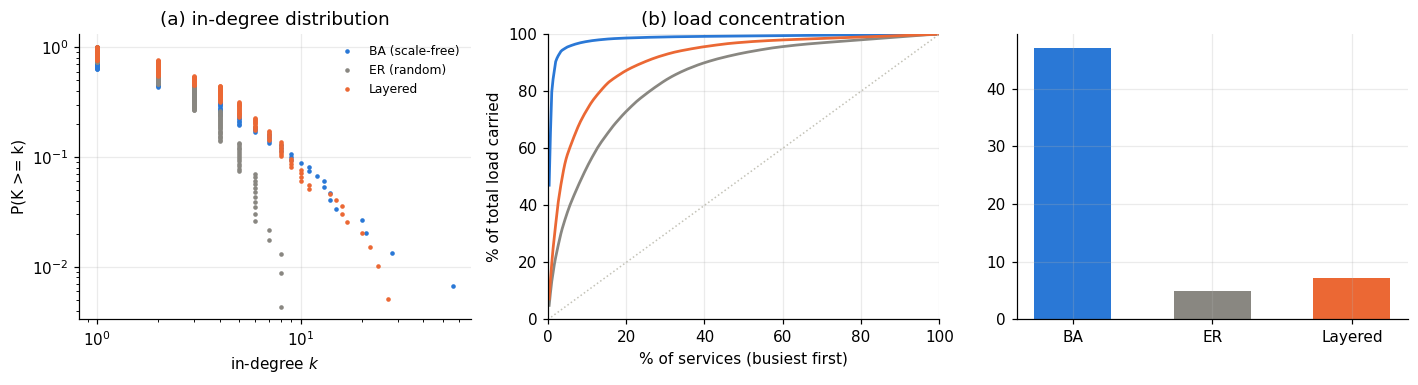

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
colors = {"BA (scale-free)": "#2a78d6", "ER (random)": "#898781", "Layered": "#eb6834"}

# (a) in-degree complementary CDF, log-log
ax = axes[0]
for name, G in GRAPHS.items():
    d = np.sort(np.array([G.in_degree(n) for n in G.nodes()]))
    d = d[d > 0]
    ccdf = 1.0 - np.arange(len(d)) / len(d)
    ax.loglog(d, ccdf, marker=".", ls="none", ms=4,
              color=colors[name], label=name)
ax.set_xlabel("in-degree $k$"); ax.set_ylabel("P(K >= k)")
ax.set_title("(a) in-degree distribution"); ax.legend(fontsize=8, frameon=False)

# (b) load concentration curve
ax = axes[1]
for name in GRAPHS:
    loads = np.sort(np.array(list(LOADS[name].values())))[::-1]
    ax.plot(100 * np.arange(1, len(loads) + 1) / len(loads),
            100 * np.cumsum(loads) / loads.sum(), color=colors[name], lw=1.8,
            label=name)
ax.plot([0, 100], [0, 100], ls=":", color="#c3c2b7", lw=1)
ax.set_xlabel("% of services (busiest first)")
ax.set_ylabel("% of total load carried")
ax.set_title("(b) load concentration"); ax.set_xlim(0, 100); ax.set_ylim(0, 100)

# (c) cost of removing the single busiest node
ax = axes[2]
names, vals = [], []
for name, G in GRAPHS.items():
    L = LOADS[name]
    hub = max(L, key=L.get)
    after = propagate_load(G, removed={hub})
    names.append(name)
    vals.append(100 * (1 - sum(after.values()) / sum(L.values())))
ax.bar(range(len(names)), vals, color=[colors[n] for n in names], width=0.55)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.split(" ")[0] for n in names])

plt.tight_layout(); plt.show()

**Reading the figures.**

*(a)* The scale-free graph's in-degree distribution has a long tail on log-log
axes: most services are called by one or two things, a few by dozens. The random
graph falls off sharply — it has no hubs at all.

*(b)* The diagonal would be perfect equality. The further a curve bows above it,
the more concentrated the load. On the scale-free graph a tiny fraction of
services carries almost all the traffic.

*(c)* Direct consequence: on the scale-free graph, removing one service costs a
large share of everything the platform serves. On the random graph, very little.

This is the **robust-yet-fragile** property from the network literature. It is
the reason topology is an independent variable throughout this project rather
than a fixed background assumption.

## 5. Open modelling decision

Load is multiplicative: a service passes amplified load downstream, because one
request can trigger several calls. Compounded over long chains this grows fast.

The cell below quantifies it.

In [ ]:
print(f"{'topology':<18}{'total system load':>20}{'amplification':>18}")
print("-" * 56)
for name, G in GRAPHS.items():
    n_entry = sum(1 for n in G.nodes() if G.in_degree(n) == 0)
    total = sum(LOADS[name].values())
    injected = n_entry * EXTERNAL_RATE
    print(f"{name:<18}{total:>20,.0f}{total/injected:>18,.1f}x")

    depth = nx.dag_longest_path_length(G)
    print(f"{'':18}longest call chain: {depth} hops")

topology             total system load     amplification
--------------------------------------------------------
BA (scale-free)              2,231,700             147.8x
                  longest call chain: 15 hops
ER (random)                    283,373              40.5x
                  longest call chain: 10 hops
Layered                        587,473              57.0x
                  longest call chain: 4 hops


The direction is right — a shared database genuinely does serve far more
queries per second than the gateway that fronts it. But the magnitude on the
scale-free graph is extreme, driven by long call chains compounding.

Three ways to handle it:

1. **Cap mean fan-out weight** at or below 1.0 so amplification stays bounded.
   Simplest, slightly less realistic.
2. **Use the layered graph as the primary topology.** Its bounded depth keeps
   amplification reasonable, and it is the realistic generator anyway. BA and ER
   stay as the topology-comparison arm, where extreme concentration is
   precisely the point being made.
3. **Normalise damage by served work** rather than node count, which turns the
   concentration into a reported finding rather than a distortion.

**Decision taken: (2), with (3) for reporting.** Recorded in `docs/decisions.md`.
The layered graph is the primary topology for the main experiments; BA and ER
are used where topology is the independent variable; damage is reported both as
a node fraction and as a share of served work.

## 6. Next

Step 1 is done and validated. What follows, in order:

| Step | What | Validation gate |
|---|---|---|
| 2 | Worm spreading along trust edges | measured epidemic threshold matches $\lambda_c \approx \langle k \rangle / \langle k^2 \rangle$ |
| 3 | Capacity cascade under node removal | sharp transition in failed fraction as $\alpha$ falls |
| 4 | Anomaly detector (ROC) and quarantine response | false-positive rate matches the chosen operating point |
| 5 | Sensitivity sweep | the U-curve, damage decomposed three ways |
| 6 | Attacker-absent control | tests H2: does the defender alone go supercritical |

Steps 2 and 3 are the two published baselines. Neither is novel — that is the
point. Reproducing known results is what establishes that the model is correct
before anything new is built on it.